In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print(df.shape)

(891, 12)


In [ ]:
rows, columns = df.shape

print("Rows =", rows)
print("Columns =", columns)

Rows = 891
Columns = 12


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [ ]:
categorical = df.select_dtypes(include=['object']).columns

print(categorical)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


# Titanic Dataset Summary

The Titanic dataset contains 891 rows and 12 columns.

The dataset includes both numerical and categorical features.

Some columns contain missing values such as Age, Cabin, and Embarked.

Cabin has the highest number of missing values.

This exploratory analysis helps us understand the dataset before applying machine learning models.

# Task 2: Data Cleaning and Visualization

In this section, I will clean the Titanic dataset and visualize important patterns in the data.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin because most of its values are missing
df = df.drop(columns=['Cabin'])

# Check missing values after cleaning
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Missing Value Handling

I filled the missing values in the Age column using the median because age is a numerical feature and the median is less affected by extreme values.

I filled the missing values in the Embarked column using the mode because it is a categorical feature.

I dropped the Cabin column because a large majority of its values were missing, making it difficult to use reliably without introducing too much imputation.

## Outlier Detection

A boxplot is used to identify potential outliers in the Fare column.

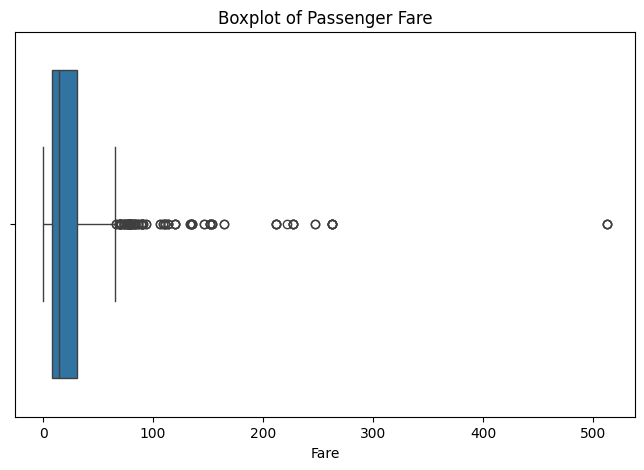

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Passenger Fare')
plt.xlabel('Fare')
plt.show()

## 1. Age Distribution

The histogram shows the distribution of passenger ages in the Titanic dataset.


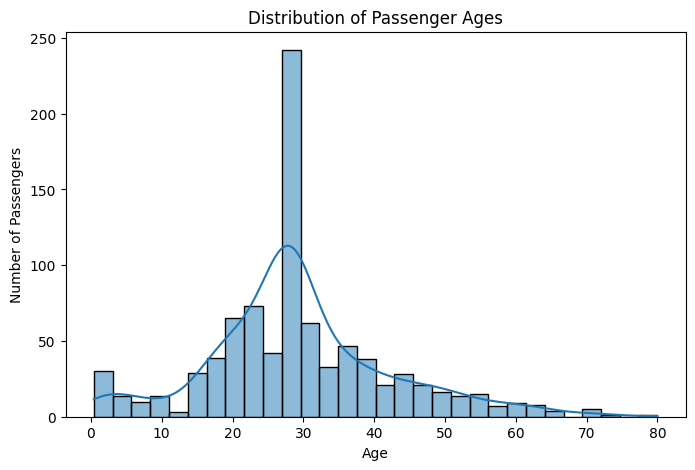

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

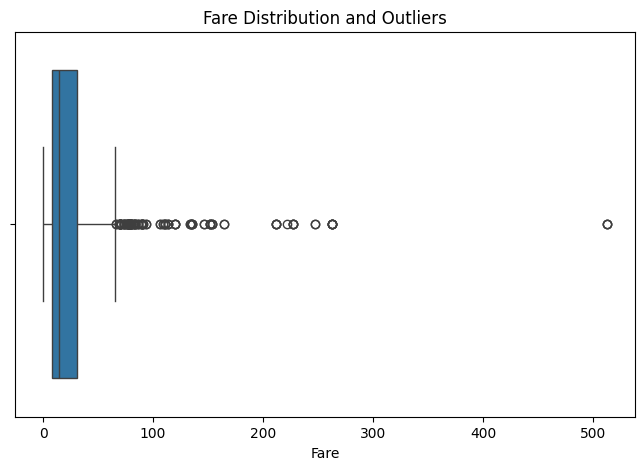

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fare')
plt.title('Fare Distribution and Outliers')
plt.xlabel('Fare')
plt.show()

## 3. Survival Rate by Gender

The bar chart compares the number of passengers who survived and did not survive based on gender.

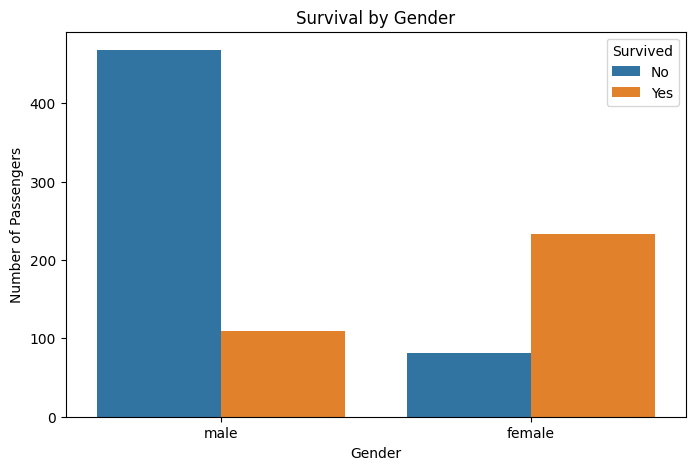

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## 4. Correlation Heatmap

The correlation heatmap shows the relationships between numerical features in the Titanic dataset.

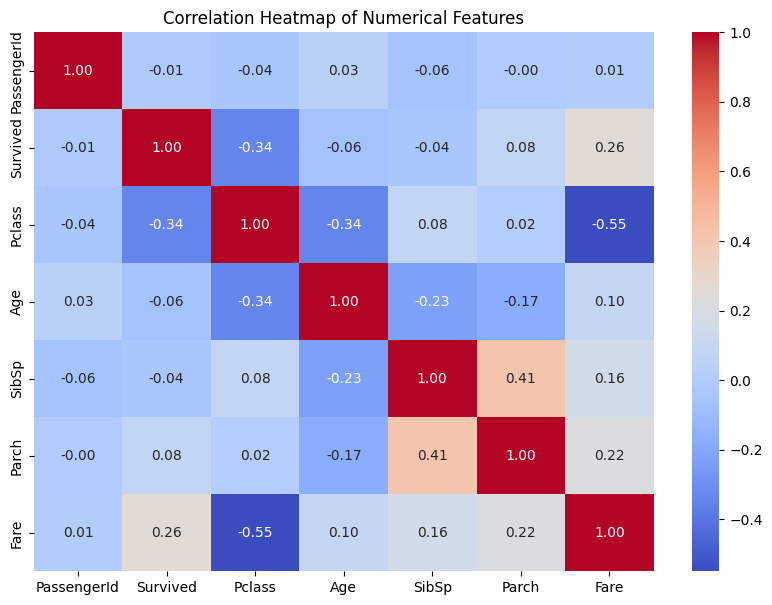

In [ ]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Feature Most Affecting Survival

I think Sex is one of the features that most strongly affects survival in the Titanic dataset. The survival visualization shows that female passengers had a much higher survival rate than male passengers. This suggests that gender played an important role in the chances of survival. Passenger class (Pclass) also appears to be an important factor because passengers in higher classes generally had better access to resources and evacuation opportunities.

In [ ]:
print("Dataset shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning: (891, 11)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Week 2: Predict Titanic Survival — First Classification Model

In this section, I will build a Logistic Regression classification model to predict whether a Titanic passenger survived or did not survive.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin because it contains many missing values
df = df.drop(columns=['Cabin'])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

In [ ]:
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

In [ ]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8044692737430168
Model Accuracy (%): 80.45 %


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


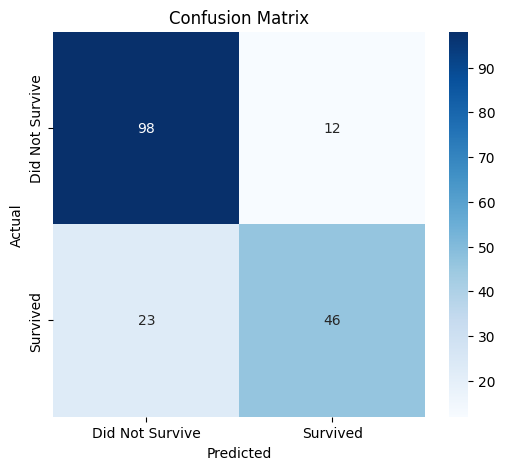

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Confusion Matrix Explanation

The confusion matrix shows how well the Logistic Regression model classified passengers into two classes: survived and did not survive.

True Negatives (TN) are passengers who did not survive and were correctly predicted as not surviving.

True Positives (TP) are passengers who survived and were correctly predicted as surviving.

False Positives (FP) are passengers who did not survive but were incorrectly predicted to survive.

False Negatives (FN) are passengers who survived but were incorrectly predicted not to survive.

Overall, the confusion matrix helps us understand not only the accuracy of the model but also the types of prediction errors it makes.

In [ ]:
print("===== MODEL RESULTS =====")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(cm)

===== MODEL RESULTS =====
Training Samples: 712
Testing Samples: 179
Accuracy: 80.45 %

Confusion Matrix:
[[98 12]
 [23 46]]


## Final Model Summary

A Logistic Regression classification model was trained to predict Titanic passenger survival.

The dataset was divided into 80% training data and 20% testing data using train_test_split.

Categorical features such as Sex and Embarked were converted into numerical features using pandas get_dummies().

The model was evaluated using accuracy_score and a confusion matrix.

The final model achieved an accuracy of approximately [80.45]% on the test dataset.

The confusion matrix provided additional information about correct predictions and classification errors.

# Week 3: Model Evaluation & Tuning — Beyond Accuracy

In this task, I will evaluate my Titanic Logistic Regression classification model using precision, recall, and F1-score. I will then use GridSearchCV to tune the model's hyperparameters and compare its performance before and after tuning.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset
df = pd.read_csv("train.csv")

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin
df = df.drop(columns=['Cabin'])

# Select features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

# Encode categorical columns
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train original Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Original model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Original Model Accuracy:", round(accuracy * 100, 2), "%")

Original Model Accuracy: 80.45 %


In [4]:
print("Classification Report - Original Model")
print(classification_report(y_test, y_pred))

Classification Report - Original Model
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [5]:
from sklearn.model_selection import GridSearchCV

In [6]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [7]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [8]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [9]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}


In [10]:
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Model Results")
print("Accuracy:", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1-score:", round(tuned_f1, 4))

Tuned Model Results
Accuracy: 0.7989
Precision: 0.8
Recall: 0.6377
F1-score: 0.7097


In [12]:
print("Classification Report - Tuned Model")
print(classification_report(y_test, tuned_pred))

Classification Report - Tuned Model
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.64      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



## Before vs After Hyperparameter Tuning

| Metric | Original Model | Tuned Model |
|---|---:|---:|
| Accuracy | 80.45% | 79.89% |
| Precision | 79.00% | 80.00% |
| Recall | 67.00% | 63.77% |
| F1-score | 72.00% | 70.97% |

The original model achieved an accuracy of 80.45%, while the tuned model achieved 79.89%. Precision slightly improved from 79.00% to 80.00%, but recall decreased from 67.00% to 63.77%. The F1-score also decreased from 72.00% to 70.97%. Overall, hyperparameter tuning did not significantly improve the model's performance on the test set, although it slightly improved precision.

## Before vs After Hyperparameter Tuning

The original Logistic Regression model achieved an accuracy of 80.45%, while the tuned model achieved an accuracy of 79.89%.

For the Survived class, precision slightly improved from 79% to 80%. However, recall decreased from 67% to 64%, and the F1-score decreased from 72% to 71%.

Overall, the tuned model did not improve the overall performance compared to the original model. However, the tuning process slightly improved precision and demonstrated how different hyperparameter settings can affect different evaluation metrics.

The best hyperparameters selected by GridSearchCV were C = 0.1 and solver = lbfgs.
